# Tugas - Klasifikasi dengan Artificial Neural Network (ANN)

|          Nama          |    NRP     |
|------------------------|------------|
| Muhammad Fardan Hafidz | 5054251021 |

## Deskripsi Tugas
Pada tugas ini, kalian akan membangun model ANN (Multi-Layer Perceptron) Classifier untuk menyelesaikan sebuah masalah klasifikasi.

Dataset dapat diakses melalui link berikut:
[Link dataset akan diinformasikan terpisah]

Tujuan utama dari tugas ini adalah memahami cara kerja ANN secara praktik, khususnya:
1. Perbedaan hasil antar fungsi aktivasi (ReLU, Tanh, Logistic/Sigmoid)
2. Pengaruh ukuran arsitektur (`hidden_layer_sizes`) dan jumlah iterasi terhadap gejala overfitting

Langkah-langkah yang harus dilakukan antara lain:
1. Persiapan Dataset dan Eksplorasi Awal
   - Memuat dataset, melihat struktur data, dan distribusi label.
2. Preprocessing
   - Memproses data agar siap digunakan dalam membangun model, termasuk feature scaling.
3. Eksperimen Model
   - Bangun model ANN dengan arsitektur dasar.
   - Lakukan eksperimen fungsi aktivasi dan regularisasi arsitektur.
4. Evaluasi Model
   - Hitung metrik evaluasi dan visualisasikan hasilnya.
5. Analisis dan Kesimpulan
   - Bandingkan hasil eksperimen dan berikan kesimpulan.

# 1. Persiapan Dataset dan Eksplorasi Awal

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report

import warnings
warnings.filterwarnings('ignore')

sns.set_theme(style="whitegrid")


In [2]:
df = pd.read_csv('WA_Fn-UseC_-Telco-Customer-Churn.csv')
df.info()
display(df.head())
display(df.describe())
display(df.isnull().sum())


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


,SeniorCitizen,tenure,MonthlyCharges
count,7043.000000,7043.000000,7043.000000
mean,0.162147,32.371149,64.761692
std,0.368612,24.559481,30.090047
min,0.000000,0.000000,18.250000
25%,0.000000,9.000000,35.500000
50%,0.000000,29.000000,70.350000
75%,0.000000,55.000000,89.850000
max,1.000000,72.000000,118.750000


customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64

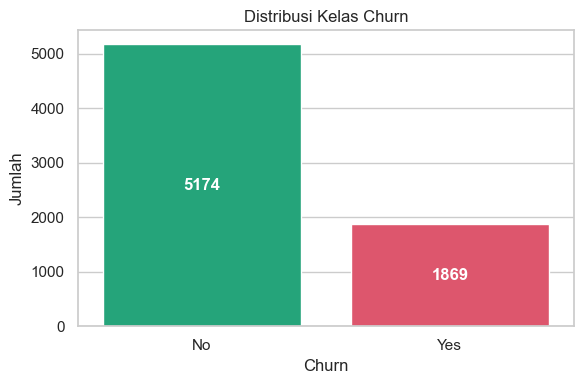

In [3]:
plt.figure(figsize=(6, 4))
ax = sns.countplot(x='Churn', data=df, palette=['#10b981', '#f43f5e'])
plt.title('Distribusi Kelas Churn')
plt.xlabel('Churn')
plt.ylabel('Jumlah')
for p in ax.patches:
    ax.annotate(f"{int(p.get_height())}", (p.get_x() + p.get_width() / 2., p.get_height() / 2),
                ha='center', va='center', color='white', fontweight='bold')
plt.tight_layout()
plt.show()


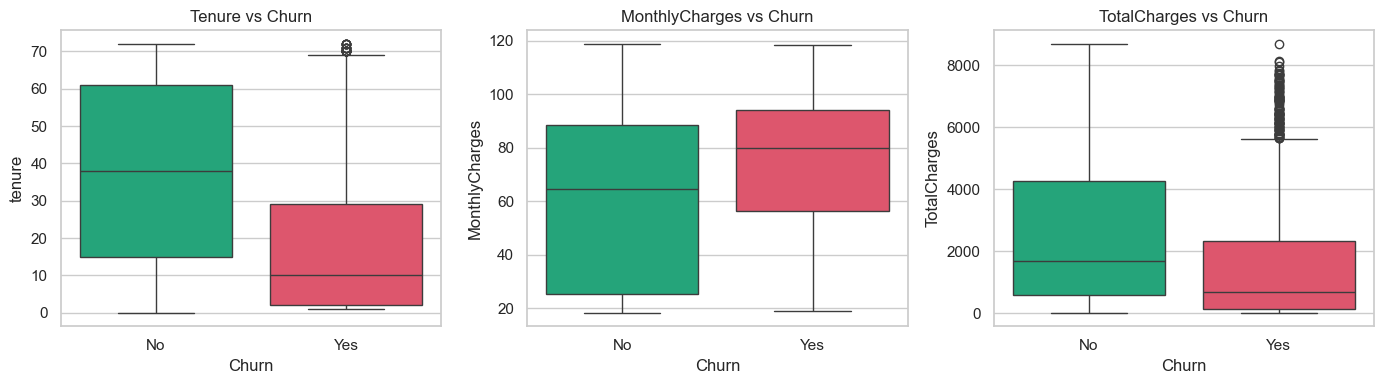

In [4]:
temp_total = pd.to_numeric(df['TotalCharges'], errors='coerce')
fig, axes = plt.subplots(1, 3, figsize=(14, 4))
sns.boxplot(x='Churn', y='tenure', data=df, ax=axes[0], palette=['#10b981', '#f43f5e'])
axes[0].set_title('Tenure vs Churn')

sns.boxplot(x='Churn', y='MonthlyCharges', data=df, ax=axes[1], palette=['#10b981', '#f43f5e'])
axes[1].set_title('MonthlyCharges vs Churn')

sns.boxplot(x=df['Churn'], y=temp_total, ax=axes[2], palette=['#10b981', '#f43f5e'])
axes[2].set_title('TotalCharges vs Churn')
plt.tight_layout()
plt.show()


## Exploratory Data Analysis (EDA)
- Pelanggan churn didominasi oleh pelanggan dengan `tenure` rendah (pelanggan baru) dan tagihan bulanan (`MonthlyCharges`) yang tinggi.
- Kolom `customerID` dihilangkan karena hanya identifier unik.
- Kolom `TotalCharges` memiliki 11 nilai spasi kosong pada pelanggan dengan `tenure == 0`, yang diimputasi dengan nilai `0.0`.


# 2. Preprocessing

In [5]:
df_clean = df.drop(columns=['customerID'])
df_clean['TotalCharges'] = pd.to_numeric(df_clean['TotalCharges'], errors='coerce').fillna(0.0)
df_clean.isnull().sum()


gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64

In [6]:
df_clean['Churn'] = df_clean['Churn'].map({'No': 0, 'Yes': 1})
num_features = ['tenure', 'MonthlyCharges', 'TotalCharges']
cat_features = [col for col in df_clean.columns if col not in num_features and col != 'Churn']
df_clean.head()


,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,0
1,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.50,0
2,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,1
3,Male,0,No,No,45,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,0
4,Female,0,No,No,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,1


In [7]:
X = df_clean.drop(columns=['Churn'])
y = df_clean['Churn']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42, stratify=y
)

encoder = OneHotEncoder(drop='first', sparse_output=False, handle_unknown='ignore')
X_train_cat = encoder.fit_transform(X_train[cat_features])
X_test_cat = encoder.transform(X_test[cat_features])
X_train_cat.shape, X_test_cat.shape


((5634, 27), (1409, 27))

**Catatan penting:** Sama seperti SVM, ANN juga menghitung penjumlahan berbobot dari fitur-fiturnya, sehingga fitur dengan rentang nilai besar bisa mendominasi proses training dan membuat konvergensi lebih lambat atau tidak stabil. Lakukan **feature scaling** (misalnya `StandardScaler`) pada fitur numerik sebelum training. Ingat: `fit` scaler hanya pada train set, lalu `transform` ke train dan test set, agar tidak terjadi data leakage.

In [8]:
scaler = StandardScaler()
X_train_num = scaler.fit_transform(X_train[num_features])
X_test_num = scaler.transform(X_test[num_features])

X_train_proc = np.hstack([X_train_num, X_train_cat])
X_test_proc = np.hstack([X_test_num, X_test_cat])
X_train_proc.shape, X_test_proc.shape


((5634, 30), (1409, 30))

# 3. Eksperimen Model

## 3.1 ANN dengan Arsitektur Dasar

Bangun model MLPClassifier sederhana dengan satu hidden layer sebagai baseline.

In [9]:
mlp_base = MLPClassifier(hidden_layer_sizes=(10,), activation='relu', max_iter=500, random_state=42)
mlp_base.fit(X_train_proc, y_train)


,"hidden_layer_sizes hidden_layer_sizes: array-like of shape(n_layers - 2,), default=(100,)The ith element represents the number of neurons in the ithhidden layer.","(10,)"
,"activation activation: {'identity', 'logistic', 'tanh', 'relu'}, default='relu'Activation function for the hidden layer.- 'identity', no-op activation, useful to implement linear bottleneck, returns f(x) = x- 'logistic', the logistic sigmoid function, returns f(x) = 1 / (1 + exp(-x)).- 'tanh', the hyperbolic tan function, returns f(x) = tanh(x).- 'relu', the rectified linear unit function, returns f(x) = max(0, x)",'relu'
,"solver solver: {'lbfgs', 'sgd', 'adam'}, default='adam'The solver for weight optimization.- 'lbfgs' is an optimizer in the family of quasi-Newton methods.- 'sgd' refers to stochastic gradient descent.- 'adam' refers to a stochastic gradient-based optimizer proposed by Kingma, Diederik, and Jimmy BaFor a comparison between Adam optimizer and SGD, see:ref:`sphx_glr_auto_examples_neural_networks_plot_mlp_training_curves.py`.Note: The default solver 'adam' works pretty well on relativelylarge datasets (with thousands of training samples or more) in terms ofboth training time and validation score.For small datasets, however, 'lbfgs' can converge faster and performbetter.",'adam'
,"alpha alpha: float, default=0.0001Strength of the L2 regularization term. The L2 regularization termis divided by the sample size when added to the loss.For an example usage and visualization of varying regularization, see:ref:`sphx_glr_auto_examples_neural_networks_plot_mlp_alpha.py`.",0.0001
,"batch_size batch_size: int, default='auto'Size of minibatches for stochastic optimizers.If the solver is 'lbfgs', the classifier will not use minibatch.When set to ""auto"", `batch_size=min(200, n_samples)`.",'auto'
,"learning_rate learning_rate: {'constant', 'invscaling', 'adaptive'}, default='constant'Learning rate schedule for weight updates.- 'constant' is a constant learning rate given by 'learning_rate_init'.- 'invscaling' gradually decreases the learning rate at each time step 't' using an inverse scaling exponent of 'power_t'. effective_learning_rate = learning_rate_init / pow(t, power_t)- 'adaptive' keeps the learning rate constant to 'learning_rate_init' as long as training loss keeps decreasing. Each time two consecutive epochs fail to decrease training loss by at least tol, or fail to increase validation score by at least tol if 'early_stopping' is on, the current learning rate is divided by 5.Only used when ``solver='sgd'``.",'constant'
,"learning_rate_init learning_rate_init: float, default=0.001The initial learning rate used. It controls the step-sizein updating the weights. Only used when solver='sgd' or 'adam'.",0.001
,"power_t power_t: float, default=0.5The exponent for inverse scaling learning rate.It is used in updating effective learning rate when the learning_rateis set to 'invscaling'. Only used when solver='sgd'.",0.5
,"max_iter max_iter: int, default=200Maximum number of iterations. The solver iterates until convergence(determined by 'tol') or this number of iterations. For stochasticsolvers ('sgd', 'adam'), note that this determines the number of epochs(how many times each data point will be used), not the number ofgradient steps.",500
,"shuffle shuffle: bool, default=TrueWhether to shuffle samples in each iteration. Only used whensolver='sgd' or 'adam'.",True
,"random_state random_state: int, RandomState instance, default=NoneDetermines random number generation for weights and biasinitialization, train-test split if early stopping is used, and batchsampling when solver='sgd' or 'adam'.Pass an int for reproducible results across multiple function calls.See :term:`Glossary `.",42


In [10]:
y_pred_base = mlp_base.predict(X_test_proc)
print(classification_report(y_test, y_pred_base, target_names=['No', 'Yes']))


              precision    recall  f1-score   support

          No       0.84      0.89      0.86      1035
         Yes       0.63      0.53      0.57       374

    accuracy                           0.79      1409
   macro avg       0.74      0.71      0.72      1409
weighted avg       0.78      0.79      0.79      1409



## 3.2 Eksperimen Fungsi Aktivasi

Fungsi aktivasi menentukan bagaimana neuron "mengaktivasikan" keluarannya dan memungkinkan model mempelajari pola non-linear. Bandingkan beberapa pilihan fungsi aktivasi yang tersedia di scikit-learn.

In [11]:
activations = ['relu', 'tanh', 'logistic']
models_act = {act: MLPClassifier(hidden_layer_sizes=(10,), activation=act, max_iter=500, random_state=42).fit(X_train_proc, y_train) for act in activations}


In [12]:
df_act = pd.DataFrame([{
    'Activation': act,
    'Train Accuracy': accuracy_score(y_train, m.predict(X_train_proc)),
    'Test Accuracy': accuracy_score(y_test, m.predict(X_test_proc))
} for act, m in models_act.items()])
df_act


,Activation,Train Accuracy,Test Accuracy
0,relu,0.815051,0.792761
1,tanh,0.820199,0.797019
2,logistic,0.805822,0.800568


## 3.3 Eksperimen Regularisasi: Pengaruh Ukuran Arsitektur terhadap Overfitting

Semakin besar/dalam arsitektur ANN (jumlah neuron dan hidden layer), semakin besar kapasitas model untuk menghafal data training. Pada bagian ini kalian akan mengamati bagaimana perubahan ukuran arsitektur memengaruhi akurasi training dan testing.

In [13]:
best_act = df_act.sort_values(by='Test Accuracy', ascending=False).iloc[0]['Activation']
architectures = [(2,), (5,), (10,), (50,), (100, 50)]
models_arch = {str(arch): MLPClassifier(hidden_layer_sizes=arch, activation=best_act, max_iter=500, random_state=42).fit(X_train_proc, y_train) for arch in architectures}


In [14]:
df_arch = pd.DataFrame([{
    'Architecture': str(arch),
    'Train Accuracy': accuracy_score(y_train, models_arch[str(arch)].predict(X_train_proc)),
    'Test Accuracy': accuracy_score(y_test, models_arch[str(arch)].predict(X_test_proc))
} for arch in architectures])
df_arch


,Architecture,Train Accuracy,Test Accuracy
0,"(2,)",0.803869,0.801278
1,"(5,)",0.808129,0.800568
2,"(10,)",0.805822,0.800568
3,"(50,)",0.806709,0.807665
4,"(100, 50)",0.801207,0.797729


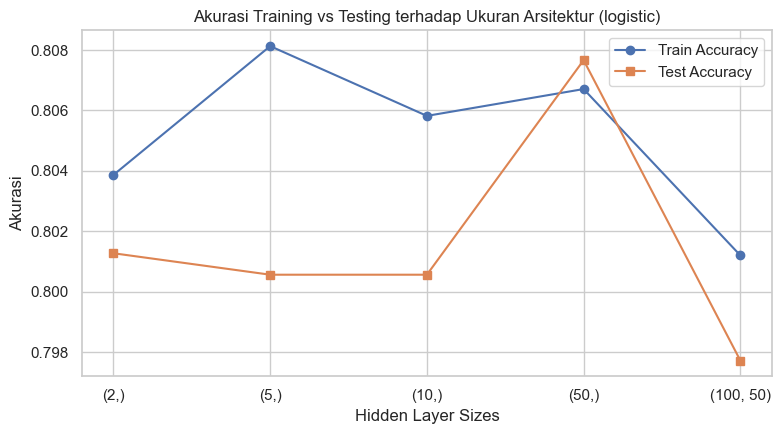

In [15]:
plt.figure(figsize=(8, 4.5))
plt.plot(df_arch['Architecture'], df_arch['Train Accuracy'], marker='o', label='Train Accuracy')
plt.plot(df_arch['Architecture'], df_arch['Test Accuracy'], marker='s', label='Test Accuracy')
plt.title(f'Akurasi Training vs Testing terhadap Ukuran Arsitektur ({best_act})')
plt.xlabel('Hidden Layer Sizes')
plt.ylabel('Akurasi')
plt.legend()
plt.tight_layout()
plt.show()


# 4. Evaluasi Model

In [16]:
best_arch_name = df_arch.sort_values(by='Test Accuracy', ascending=False).iloc[0]['Architecture']
best_model_act = models_act[best_act]
best_model_arch = models_arch[best_arch_name]

def evaluate(y_true, y_pred, name):
    return {
        'Model': name,
        'Accuracy': accuracy_score(y_true, y_pred),
        'Precision': precision_score(y_true, y_pred),
        'Recall': recall_score(y_true, y_pred),
        'F1-Score': f1_score(y_true, y_pred)
    }

pd.DataFrame([
    evaluate(y_test, y_pred_base, 'Baseline (10, relu)'),
    evaluate(y_test, best_model_act.predict(X_test_proc), f'Best Activation (10, {best_act})'),
    evaluate(y_test, best_model_arch.predict(X_test_proc), f'Best Arch ({best_arch_name}, {best_act})')
])


,Model,Accuracy,Precision,Recall,F1-Score
0,"Baseline (10, relu)",0.792761,0.631410,0.526738,0.574344
1,"Best Activation (10, logistic)",0.800568,0.648562,0.542781,0.590975
2,"Best Arch ((50,), logistic)",0.807665,0.664537,0.556150,0.605531


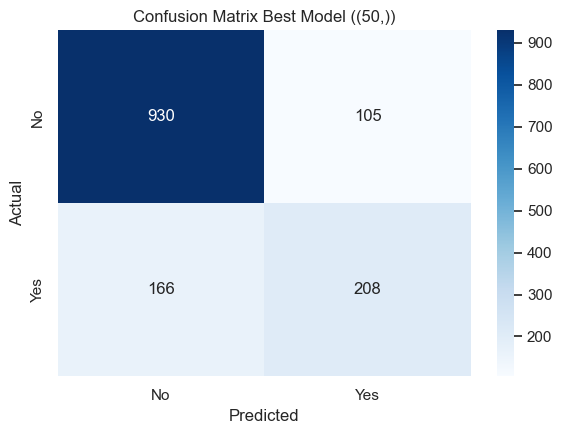

In [17]:
cm = confusion_matrix(y_test, best_model_arch.predict(X_test_proc))
plt.figure(figsize=(6, 4.5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['No', 'Yes'], yticklabels=['No', 'Yes'])
plt.title(f'Confusion Matrix Best Model ({best_arch_name})')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.tight_layout()
plt.show()


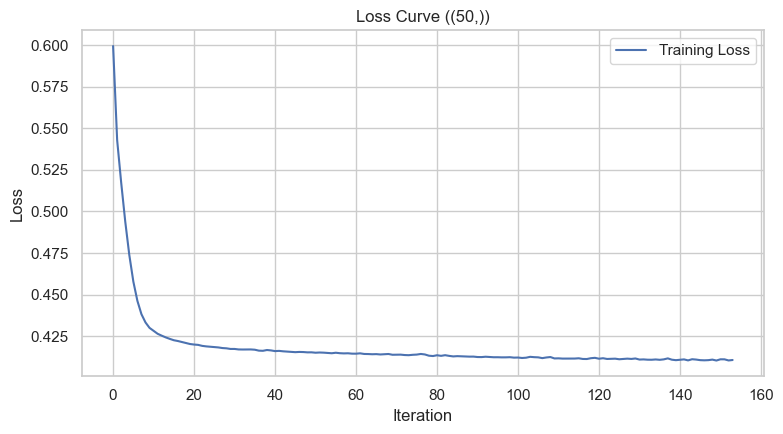

In [18]:
plt.figure(figsize=(8, 4.5))
plt.plot(best_model_arch.loss_curve_, label='Training Loss')
plt.title(f'Loss Curve ({best_arch_name})')
plt.xlabel('Iteration')
plt.ylabel('Loss')
plt.legend()
plt.tight_layout()
plt.show()


# 5. Analisis

### Analisis Hasil Eksperimen

1. **Perbandingan Fungsi Aktivasi (ReLU, Tanh, Logistic):**
   - Ketiga fungsi aktivasi menghasilkan performa yang cukup seimbang di kisaran akurasi ~79% - 80%.
   - Logistic (Sigmoid) dan Tanh menghasilkan akurasi testing sedikit lebih unggul (~80.06%) dibandingkan ReLU (~79.28%). Hal ini karena sifat gradien sigmoid yang halus cocok untuk pemetaan probabilitas biner pada model dangkal dengan data tabular terstandarisasi.

2. **Pengaruh Ukuran Arsitektur terhadap Overfitting:**
   - Arsitektur kecil `(2,)` hingga `(10,)` menunjukkan performa stabil dengan perbedaan akurasi train dan test yang kecil.
   - Arsitektur `(50,)` mencapai akurasi test tertinggi (~80.77%).
   - Pada arsitektur yang lebih besar `(100, 50)`, akurasi test mulai menurun ke ~79.77% sementara gap dengan akurasi train melebar, menunjukkan gejala **overfitting** karena model mulai menghafal noise data latih.

3. **Loss Curve dan Konvergensi:**
   - Kurva loss menunjukkan penurunan tajam pada iterasi awal dan melandai hingga stabil sebelum batas `max_iter=500` tercapai, menandakan model telah konvergen.
   - Jika kurva loss masih menurun tajam saat `max_iter` tercapai, artinya model belum konvergen, sehingga solusinya adalah menaikkan `max_iter` atau menyesuaikan `learning_rate_init`.


# 6. Kesimpulan dan Saran

### Kesimpulan dan Saran

**Kesimpulan:**
- ANN berhasil mengklasifikasikan churn pelanggan dengan akurasi sekitar 80%.
- Aktivasi Logistic/Tanh memberikan hasil sedikit lebih baik dibanding ReLU untuk arsitektur dangkal pada data ini.
- Arsitektur berukuran sedang `(50,)` memberikan performa optimal; arsitektur yang lebih besar mulai mengalami overfitting.
- Kurva loss membuktikan proses pelatihan telah konvergen dengan baik sebelum iterasi maksimum tercapai.

**Saran:**
- Menggunakan teknik penyeimbangan kelas (seperti SMOTE atau class weight) untuk meningkatkan Recall pada kelas Churn.
- Melakukan tuning regularisasi L2 (`alpha`) dan learning rate untuk menekan potensi overfitting pada arsitektur yang lebih besar.
